# Imports + Helper Functions

In [154]:
import torch
%env CUDA_VISIBLE_DEVICES 2
torch.cuda.device_count()

env: CUDA_VISIBLE_DEVICES=2


1

In [2]:
import geopandas as gpd
from sentle import sentle
import os
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import xarray as xr
from equi7grid_lite import Equi7Grid

In [156]:
# Set font sizes for various components
plt.rcParams.update({
    'font.size': 14,           # Global font size
    'axes.titlesize': 18,      # Title font size
    'axes.labelsize': 16,      # X and Y label font size
    'xtick.labelsize': 14,     # X tick label font size
    'ytick.labelsize': 14,     # Y tick label font size
})

In [4]:
def remove_outliers(ds, method='median', user_factor=2, z_pval=0.05):
    """
    Takes an xarray dataset containing vegetation index variable and removes outliers within 
    the timeseries on a per-pixel basis. The resulting dataset contains the timeseries 
    with outliers set to nan. Can work on datasets with or without existing nan values.
    
    Parameters
    ----------
    ds: xarray Dataset
        A two-dimensional or multi-dimensional array 
    method: str
        The outlier detection method to apply to the dataset. The median method detects 
        outliers by calculating if values in pixel timeseries deviate more than a maximum 
        deviation (cutoff) from the median in a moving window (half window width = number 
        of values per year / 7) and it is lower than the mean value of its immediate neighbors 
        minus the cutoff or it is larger than the highest value of its immediate neighbor plus 
        The cutoff is the standard deviation of the entire time-series times a factor given by 
        the user. The second method, zscore, is similar but uses zscore to detect whether outlier
        is signficicantly (i.e. p-value) outside the population.
    user_factor: float
        An value between 0 to 10 which is used to 'multiply' the threshold cutoff. A higher factor 
        value results in few outliers (i.e. only the biggest outliers). Default factor is 2.
    z_pval: float
        The p-value for zscore method. A more significant p-value (i.e. 0.01) results in fewer
        outliers, a less significant p-value (i.e 0.1) results in more. Default is 0.05.
    Returns
    -------
    ds : xarray Dataset
        The original xarray Dataset inputted into the function, with a all detected outliers in the
        all the variables set to nan.
    """
    
    # notify user
    print('Outlier removal method: {0} with a user factor of: {1}'.format(method, user_factor))
    
    # check if type is xr dataset
    if type(ds) != xr.Dataset:
        raise TypeError('Not a dataset. Please provide a xarray dataset.')
        
    # check if time dimension is in dataset
    if 'time' not in list(ds.dims):
        raise ValueError('Time dimension not in dataset. Please ensure dataset has a time dimension.')
    
    # # check if dataset contains veg_index variable
    # if 'veg_index' not in list(ds.data_vars):
    #     raise ValueError('Vegetation index (veg_index) not in dataset. Please generate veg_index first.')
                        
    # check if dataset is 2D or above
    #if len(ds['s2_B01'].shape) == 1:
    #    raise Exception('Remove outliers does not operate on 1D datasets. Ensure it has an x, y and time dimension.')
        
    # check if user factor provided
    if user_factor <= 0:
        raise TypeError('User factor is less than 0. Please provide a value of 0 or above.')
        
    # check if pval provided if method is zscore
    if method == 'zscore' and z_pval not in [0.1, 0.05, 0.01]:
        raise ValueError('Zscore selected but invalid pvalue provided. Ensure it is either 0.1, 0.05 or 0.01.')    
        
    # remove outliers based on user selected method
    if method in ['median', 'zscore']:
        
        # calc cutoff val per pixel i.e. stdv of pixel multiply by user-factor 
        cutoffs = ds.std('time') * user_factor

        # generate outlier mask via median or zscore method
        if method == 'median':

            # calc mask of existing nan values (nan = True) in orig ds
            ds_mask = xr.where(ds.isnull(), True, False)

            num_years = len(ds['time']) / 365  # Assuming 365 days per year

            # Define a target number of time points for the resampling
            target_num_time_points = 7  # Adjust this value as needed

            # Calculate the new window size based on the target number of time points
            win_size = int(num_years / target_num_time_points)

            # Ensure that the window size is at least 3
            if win_size < 3:
                win_size = 3
                print('> Generated roll window size less than 3, setting to default (3).')
            elif win_size % 2 == 0:
                win_size = win_size + 1
                print('> Generated roll window size is an even number, added 1 to make it odd ({0}).'.format(win_size))
            else:
                print('> Generated roll window size is: {0}'.format(win_size))


            # calc rolling median for whole dataset
            ds_med = ds.rolling(time=win_size, center=True).median()

            # calc nan mask of start/end nans from roll, replace them with orig vals
            med_mask = xr.where(ds_med.isnull(), True, False)
            med_mask = xr.where(ds_mask != med_mask, True, False)
            ds_med = xr.where(med_mask, ds, ds_med)

            # calc abs diff between orig ds and med ds vals at each pixel
            ds_diffs = abs(ds - ds_med)

            # calc mask of outliers (outlier = True) where absolute diffs exceed cutoff
            outlier_mask = xr.where(ds_diffs > cutoffs, True, False)

        elif method == 'zscore':

            # generate critical val from user provided p-value
            if z_pval == 0.01:
                crit_val = 2.3263
            elif z_pval == 0.05:
                crit_val = 1.6449
            elif z_pval == 0.1:
                crit_val = 1.2816
            else:
                raise ValueError('Zscore p-value not supported. Please use 0.1, 0.05 or 0.01.')

            # calc zscore, ignore nans in timeseries vectors
            zscores = ds.apply(zscore, nan_policy='omit', axis=0)

            # calc mask of outliers (outlier = True) where zscore exceeds critical value
            outlier_mask = xr.where(abs(zscores) > crit_val, True, False)

        # shift values left and right one time index and combine, get mean and max for each window
        lefts, rights = ds.shift(time=1).where(outlier_mask), ds.shift(time=-1).where(outlier_mask)
        #print(lefts)
        nbr_means = (lefts + rights) / 2
        nbr_maxs = np.maximum(lefts , rights) #xr.ufuncs.fmax(lefts, rights) 

        # keep nan only if middle val < mean of neighbours - cutoff or middle val > max val + cutoffs
        outlier_mask = xr.where((ds.where(outlier_mask) < (nbr_means - cutoffs)) | 
                                (ds.where(outlier_mask) > (nbr_maxs + cutoffs)), True, False)

        # flag outliers as nan in original da
        ds = xr.where(outlier_mask, np.nan, ds)
        
    else:
        raise ValueError('Provided method not supported. Please use median or zscore.')
        
    # check if any nans exist in dataset after resample and tell user
    if bool(ds.isnull().any()):
        print('> Warning: dataset contains nan values. You may want to interpolate next.')

    # notify user
    print('> Outlier removal successful.\n')

    return ds


In [81]:


###############################  Vegitation Indecies ######################################


def PSSRa (event):
    return event.B07 / event.B04

def rvi(event):
    return event.B08 / event.B04

def nbr(event):
    # Calculate the components that make up the NBR calculation
    band_diff = event.B08 - event.B12
    band_sum = event.B08 + event.B12

    # Calculate NBR and store it as a measurement in the original dataset
    return  band_diff / band_sum

def ndvi(event):
    # Calculate the components that make up the NDVI calculation
    band_diff = event.B08 - event.B04
    band_sum = event.B08 + event.B04

    # Calculate NDVI and store it as a measurement in the original dataset
    return band_diff / band_sum
    
def ndvi_re(event):
    # Calculate the components that make up the NDVI calculation
    band_diff = event.B8A - event.B04
    band_sum = event.B8A + event.B04

    # Calculate NDVI and store it as a measurement in the original dataset
    return band_diff / band_sum


def ndre(event):
    # Calculate the components that make up the NDVI calculation
    band_diff = event.B09 - event.B05
    band_sum = event.B09 + event.B05

    # Calculate NDVI and store it as a measurement in the original dataset
    return band_diff / band_sum


def ndwi(event):
    # Calculate the components that make up the NDVI calculation
    band_diff = event.B03 - event.B08
    band_sum = event.B03 + event.B08

    # Calculate NDVI and store it as a measurement in the original dataset
    return band_diff / band_sum

# Wetness = 0.1509 (Band 2) + 0.1973 (Band 3) + 0.3279 (Band 4) + 0.3406 (Band 8) – 0.7112 (Band 11) – 0.4572 (Band 12)
def tcw(event):
    tcw = 0.1509 * event.B02 + 0.1973 * event.B03 + 0.3279 * event.B04 + 0.3406 * event.B08 - 0.7112 * event.B11 - 0.4572 * event.B12
    return tcw

# Greenness = – 0.2848 (Band 2) – 0.2435 (Band 3) – 0.5436 (Band 4) + 0.7243 (Band 8) + 0.0840 (Band 11) – 0.1800 (Band 12)
def tcg(event):
    tcg = -0.2848 * event.B02 - 0.2435 * event.B03 - 0.5436 * event.B04 + 0.7243 * event.B08 + 0.0840 * event.B11 - 0.1800 * event.B12
    return tcg

# Brightness = 0.3037 (Band 2) + 0.2793 (Band 3) + 0.4743 (Band 4) + 0.5585 (Band 8) + 0.5082 (Band 11) + 0.1863 (Band 12)
def tcb(event):
    tcb = 0.3037 * event.B02 + 0.2793 * event.B03 + 0.4743 * event.B04 + 0.5585 * event.B08 + 0.5082 * event.B11 + 0.1863 * event.B12
    return tcb

def drs(event):
   
    red_band_power = event.B04 ** 2
    nir_band_power = event.B12 ** 2
    band_sqrt = np.sqrt(red_band_power + nir_band_power)

    return band_sqrt


def ndrs(event):

    drs_values = event.drs

    # Calculate the minimum and maximum values
    min_value = np.min(drs_values)
    max_value = np.max(drs_values)

    # Normalize the values to the range [0, 1]
    normalized_values = (drs_values - min_value) / (max_value - min_value)

    return normalized_values




def ndmi(event):
    # Calculate the components that make up the NDVI calculation
    band_diff = event.B08 - event.B11
    band_sum = event.B08 + event.B11

    # Calculate NDVI and store it as a measurement in the original dataset
    return band_diff / band_sum



def nirv(event, C=0.08):

    # Calculate the components that make up the NDVI calculation
    band_diff = event.B08 - event.B04
    band_sum = event.B08 + event.B04
    
    p2 = event.B08

    # Calculate NDVI and store it as a measurement in the original dataset
    ndvi = band_diff / band_sum

    nirv = (ndvi - C)* p2

    return nirv
 


def kndvi(event, sigma):
    # Extract red and near-infrared band values
    red_band_value = event.B04
    nir_band_value = event.B12
    
    # Calculate the squared difference
    squared_difference = (nir_band_value - red_band_value)
    
    # Calculate the divisor
    divisor = (2 * sigma)
    
    # Calculate the expression inside tanh
    expression = (squared_difference / divisor)**2
    
    # Calculate and return the kndvi using the hyperbolic tangent
    kndvi = np.tanh(expression)
    
    return kndvi


def kndvi05(event):

    # Calculate the components that make up the NDVI calculation
    band_diff = event.B08 - event.B04
    band_sum = event.B08 + event.B04

    mid = band_diff / band_sum

    tan = np.tanh(mid ** 2) 
    
    return tan



def k(r, s, sigma):
    return np.exp(-((r - s) ** 2) / (2 * sigma ** 2))


def kdrs(event, sigma):
    red = event.B04
    swir = event.B12

    return 2 * (1 + k(red, swir, sigma))


def kndrs(event):

    kDRS_values = event.kdrs

    # Calculate the minimum and maximum values
    min_value = np.min(kDRS_values)
    max_value = np.max(kDRS_values)

    # Normalize the values to the range [0, 1]
    normalized_values = (kDRS_values - min_value) / (max_value - min_value)

    return normalized_values


In [8]:
def calculate_area(gdf):
    """Calculate area in square meters and square kilometers for a GeoDataFrame."""
    # Set the coordinate reference system (CRS) for the GeoDataFrame to WGS84
    gdf.crs = 'EPSG:4326'
    
    # Calculate the area in degrees (not used for final calculation, but keeping it here if needed for other purposes)
    #gdf['area_degrees'] = gdf.geometry.area
    
    # Define the target projection system (e.g., UTM Zone 18N)
    target_crs = 'EPSG:32618'
    
    # Reproject the GeoDataFrame to the target projection system
    gdf_projected = gdf.to_crs(target_crs)
    
    # Calculate the area in square meters
    gdf_projected['area_meters'] = gdf_projected.geometry.area
    
    # Convert square meters to square kilometers
    gdf['areakm2'] = gdf_projected['area_meters'] / 1e6
    
    
    # Return the GeoDataFrame with the new area columns
    return gdf

# Equi7Grid

In [62]:
from dotenv import load_dotenv
import os
from pathlib import Path
env_path = Path('/net/projects/forexd/WP1/02_ImprovedLabels/Scripts/ForExD-WP1-P1/environment/.env')
load_dotenv(dotenv_path=env_path)
s2_minicubes_folder = os.getenv('EQUI7_GRIDS')
print(s2_minicubes_folder)

/net/projects/forexd/WP1/02_ImprovedLabels/Scripts/ForExD-WP1-P1/grids/


In [63]:
def generate_equi7_grid(usa_filepath, conves_path, resolution, pixel_size):
    size = resolution*pixel_size
    print(f"Resolution: {resolution}, Pixel: {pixel_size}, Minimum Grid Size: {size}")
    grid_system = Equi7Grid(min_grid_size=size) 

    # Define a POLYGON geometry
    usa = gpd.read_file(usa_filepath)
    country = usa[usa.REGION == "08"]
    region = country.explode()[0:1]

    print(f"Generate grid ...")
    # Create a grid of Equi7Grid tiles that cover the bounding box of the POLYGON geometry
    grid = grid_system.create_grid(
        level=0,
        zone="NA",
        mask=region # Only include tiles that intersect the polygon   
    )
    grid.boundary.plot()

    print(f"Load the Convex Hulls ...")
    equi7_crs = grid.crs

    conves = gpd.read_file(conves_path)
    # Reproject the GeoDataFrame to Equi7Grid
    conves_equi7 = conves.to_crs(equi7_crs)

    print(f"Intersect Convex Hulls with grids ...")
    intersected_gdf_equi7 = gpd.sjoin(grid, conves_equi7, how='inner', predicate='intersects')
    intersected_gdf_equi7 = intersected_gdf_equi7.reset_index()
    intersected_gdf_equi7 = intersected_gdf_equi7.drop(columns=['index_right','USDA_IDX','level','land','zone'])
    intersected_gdf_equi7 = intersected_gdf_equi7.drop_duplicates()
    intersected_gdf_equi7 = intersected_gdf_equi7.reset_index()
    intersected_gdf_equi7 = intersected_gdf_equi7.drop(columns=['level_0','index'])

    # Example data for region 8
    region = country.explode()[0:1]  # Adjust this line as needed to select region 8
    #region = region.to_crs(equi7_crs)
    # Plot the boundary of the intersected geometries and region 8 with enhancements
    fig, ax = plt.subplots(figsize=(12, 12))  # Adjust size as needed

    # Plot the boundaries of intersected_gdf
    intersected_gdf_equi7.boundary.plot(ax=ax, color='black', linewidth=0.6, linestyle='-', zorder=2)

    # Plot the boundary of region 8
    #region.boundary.plot(ax=ax, color='red', linewidth=0.5, linestyle='--', zorder=3)

    # Customize the plot appearance
    ax.set_title('Intersected Geometries with EQUI7 Grid and Region 8 Boundary', fontsize=18, fontweight='bold')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.grid(True, linestyle='--', alpha=0.7)  # Add grid lines for better readability

    # Set the aspect ratio of the plot to be equal
    ax.set_aspect('equal')

    # Optional: Add a legend if needed
    ax.legend([f'Intersected Geometries ({len(intersected_gdf_equi7)} grids)', 'Region 8 Boundary'], loc='upper left', fontsize=14)

    plt.show()
    
    return intersected_gdf_equi7

In [64]:
usa_filepath = '/net/projects/forexd/WP1/02_ImprovedLabels/Scripts/ForExD-WP1-P1/data/S_USA.AdministrativeRegion/S_USA.AdministrativeRegion.shp'
conves_path = "/net/projects/forexd/WP1/02_ImprovedLabels/Scripts/ForExD-WP1-P1/overlapping_results/convex_hulls_refdm.shp"
resolution=10
pixel_size=512

Resolution: 10, Pixel: 512, Minimum Grid Size: 5120
Generate grid ...
Load the Convex Hulls ...
Intersect Convex Hulls with grids ...


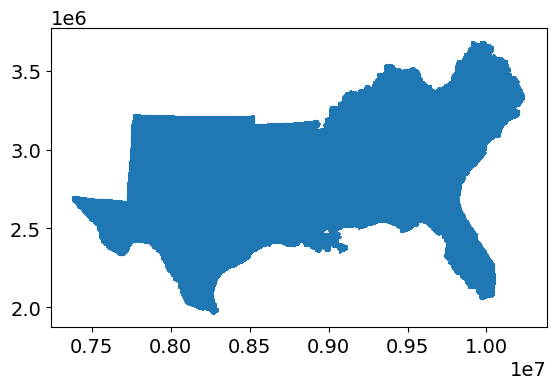

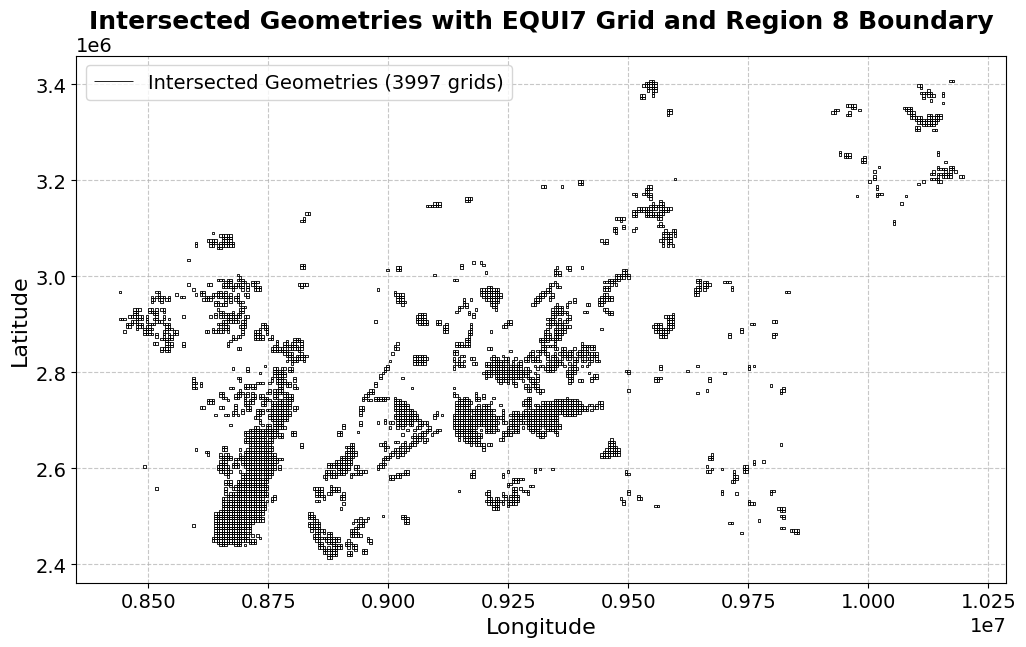

In [65]:
grid = generate_equi7_grid(usa_filepath, conves_path, resolution=resolution, pixel_size=pixel_size)
grid.to_file(f"{os.getenv('EQUI7_GRIDS')}/grid_equi7_{resolution}_{pixel_size}.shp")

In [33]:
grid = gpd.read_file(f"{os.getenv('EQUI7_GRIDS')}/grid_equi7_{resolution}_{pixel_size}.shp")
grid

,FID,geometry
0,0,"POLYGON ((8448000 2908160, 8437760 2908160, 84..."
1,1,"POLYGON ((8448000 2959360, 8437760 2959360, 84..."
2,2,"POLYGON ((8458240 2877440, 8448000 2877440, 84..."
3,3,"POLYGON ((8458240 2887680, 8448000 2887680, 84..."
4,4,"POLYGON ((8458240 2897920, 8448000 2897920, 84..."
...,...,...
1726,1726,"POLYGON ((10178560 3215360, 10168320 3215360, ..."
1727,1727,"POLYGON ((10178560 3225600, 10168320 3225600, ..."
1728,1728,"POLYGON ((10178560 3399680, 10168320 3399680, ..."
1729,1729,"POLYGON ((10188800 3215360, 10178560 3215360, ..."


# Sentle Download - transform to EPSG:4326 (not currently done)

In [ ]:
import xarray as xr
import rioxarray
import os

# Define the path to the .zarr file
path = f"{os.getenv('SENTINEL2_MINICUBES')}/1_zarr_minicube_20_res.zarr"

# Load the .zarr data
data = xr.open_zarr(path)

# Define the CRS WKT string
crs_wkt = (
    'PROJCS["Azimuthal_Equidistant",'
    'GEOGCS["WGS 84",'
    'DATUM["WGS_1984",'
    'SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],'
    'AUTHORITY["EPSG","6326"]],'
    'PRIMEM["Greenwich",0],'
    'UNIT["Degree",0.0174532925199433]],'
    'PROJECTION["Azimuthal_Equidistant"],'
    'PARAMETER["latitude_of_center",52],'
    'PARAMETER["longitude_of_center",-97.5],'
    'PARAMETER["false_easting",8264722.17686],'
    'PARAMETER["false_northing",4867518.35323],'
    'UNIT["metre",1,AUTHORITY["EPSG","9001"]],'
    'AXIS["Easting",EAST],'
    'AXIS["Northing",NORTH]]'
)

# Define the path to save the reprojected Zarr dataset
output_zarr_path = f"{os.getenv('SENTINEL2_MINICUBES')}/1_minicube_20_res_combined_reprojected_data.zarr"

# Loop over each band
for band in data.band.values:
    print(f"Processing band: {band}")
    
    # Select the specific band
    band_data = data.sel(band=band)
    
    # Assign the CRS using the WKT string
    band_data = band_data.rio.write_crs(crs_wkt)
    
    # Reproject to 'EPSG:4326'
    reprojected_band = band_data.rio.reproject("EPSG:4326")
    
    # Save the reprojected band to the Zarr store
    # Append mode ('a') to add new groups to an existing Zarr store
    reprojected_band.to_zarr(output_zarr_path, mode='a', group=f'band_{band}')

print("Reprojection and saving to Zarr completed.")


# Functions and Pipeline for Download and Preprocessing

In [3]:
import geopandas as gpd
from sentle import sentle
import os
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import xarray as xr
import warnings
from dotenv import load_dotenv
import os
from pathlib import Path
import torch
from scipy.stats import zscore
from scipy.signal import savgol_filter
from scipy.ndimage import gaussian_filter

In [4]:
# Set CUDA environment
os.environ["CUDA_VISIBLE_DEVICES"] = "2"
print(f"Available CUDA devices: {torch.cuda.device_count()}")

Available CUDA devices: 1


In [5]:
env_path = Path('/net/projects/forexd/WP1/02_ImprovedLabels/Scripts/ForExD-WP1-P1/environment/.env')
load_dotenv(dotenv_path=env_path)
s2_minicubes_folder = os.getenv('SENTINEL2_MINICUBES')
print(s2_minicubes_folder)

/net/projects/forexd/WP1/Data/S2_Cubes_IDS_R8/


In [43]:
# import torch
# %env CUDA_VISIBLE_DEVICES 2
# torch.cuda.device_count()

env: CUDA_VISIBLE_DEVICES=2


1

In [5]:
import xarray as xr
import numpy as np
from scipy.stats import zscore

def remove_outliers(ds, method='median', user_factor=2, z_pval=0.05):
    """
    Takes an xarray dataset and removes outliers within the timeseries on a per-pixel basis.
    Outliers are set to NaN. Works on datasets with or without existing NaN values.
    
    Parameters:
    -----------
    ds : xarray Dataset
        A multi-dimensional array with time, x, y, and band dimensions.
    method : str, optional
        Outlier detection method ('median' or 'zscore'). Default is 'median'.
    user_factor : float, optional
        Factor to multiply the threshold cutoff for detecting outliers. Default is 2.
    z_pval : float, optional
        P-value for the zscore method. Default is 0.05.
    
    Returns:
    --------
    ds : xarray Dataset
        The original dataset with detected outliers replaced with NaN.
    """
    
    # Notify user
    print(f"Outlier removal method: {method} with a user factor of: {user_factor}")
    
    # Check that input is a Dataset and has the necessary dimensions
    if not isinstance(ds, xr.Dataset):
        raise TypeError("Input is not an xarray Dataset.")
    
    if 'time' not in ds.dims:
        raise ValueError("Dataset does not contain a 'time' dimension.")
    
    if user_factor <= 0:
        raise ValueError("User factor must be greater than 0.")
    
    if method == 'zscore' and z_pval not in [0.1, 0.05, 0.01]:
        raise ValueError("Invalid z_pval value. Choose from 0.1, 0.05, or 0.01.")
    
    # Calculate cutoff values per pixel (std of pixel time-series multiplied by user_factor)
    cutoffs = ds.std('time') * user_factor
    
    if method == 'median':
        # Determine rolling window size
        num_years = len(ds['time']) / 365
        win_size = int(num_years / 7)  # Adjust this based on your data
        win_size = max(3, win_size + 1 if win_size % 2 == 0 else win_size)
        
        print(f"Generated rolling window size: {win_size}")
        
        # Calculate rolling median
        ds_med = ds.rolling(time=win_size, center=True).median()
        
        # Fill in NaN values in the rolling median with the original dataset
        ds_med = ds_med.where(~ds_med.isnull(), ds)
        
        # Calculate the absolute difference from the median
        ds_diff = abs(ds - ds_med)
        
        # Identify outliers where the difference exceeds the cutoff
        outlier_mask = ds_diff > cutoffs
        
    elif method == 'zscore':
        # Determine the critical z-score value based on p-value
        crit_val = {0.01: 2.3263, 0.05: 1.6449, 0.1: 1.2816}[z_pval]
        
        # Calculate z-scores along the time dimension
        zscores = ds.apply(zscore, nan_policy='omit', axis=0)
        
        # Identify outliers based on the z-score
        outlier_mask = abs(zscores) > crit_val
    
    # Shift data by one time step forward and backward for neighbor comparison
    left_neighbors = ds.shift(time=1)
    right_neighbors = ds.shift(time=-1)
    
    # Calculate mean and maximum of neighboring values
    neighbor_mean = (left_neighbors + right_neighbors) / 2
    neighbor_max = np.maximum(left_neighbors, right_neighbors)
    
    # Further refine the outlier mask using neighbor comparison
    outlier_mask = outlier_mask & ((ds < (neighbor_mean - cutoffs)) | (ds > (neighbor_max + cutoffs)))
    
    # Replace outliers with NaN in the original dataset
    ds = ds.where(~outlier_mask, np.nan)
    
    # Check for NaN values in the dataset after outlier removal
    if ds.isnull().any():
        print("> Warning: dataset contains NaN values. You may want to interpolate next.")
    
    # Notify user of successful outlier removal
    print("> Outlier removal successful.\n")
    
    return ds

In [6]:
import numpy as np
import xarray as xr
from scipy.signal import savgol_filter
from scipy.ndimage import gaussian_filter

def smooth(ds, method='savitsky', window_length=3, polyorder=1, sigma=1, mode='nearest'):
    """
    Takes an xarray dataset containing vegetation index variable and smoothes timeseries
    timeseries on a per-pixel basis. The resulting dataset contains a smoother timeseries. 
    Recommended that no nan values present in dataset.
    
    Parameters
    ----------
    ds: xarray Dataset
        A two-dimensional or multi-dimensional array containing a vegetation 
        index variable (i.e. 'veg_index').
    method: str
        The smoothing algorithm to apply to the dataset. The savitsky method uses the robust
        savitsky-golay smooting technique, as per TIMESAT. Symmetrical gaussian applies a simple 
        symmetrical gaussian. Asymmetrical gaussian applies an asymmetrical gaussian, resulting in
        a flatter peak. Double logistic applies two seperate logistic functions to give a flatter 
        peak based on TIMESAT. Default is savitsky.
    window_length: int
        The length of the filter window (i.e., the number of coefficients). Value must 
        be a positive odd integer. The larger the window length, the smoother the dataset.
        Default value is 3 (as per TIMESAT).
    polyorder: int
        The order of the polynomial used to fit the samples. Must be a odd number (int) and
        less than window_length.
    sigma: int
        Standard deviation for Gaussian kernel. The standard deviations of the Gaussian filter 
        must be provided as a single number between 1-9.
        
    Returns
    -------
    ds : xarray Dataset
        The original xarray Dataset as input into the function, with smoothed data in the
        veg_index variable.
    """
    
    # notify user
    print('Smoothing method: {0} with window length: {1}, polyorder: {2}  and mode: {3}.'.format(method, window_length, polyorder, mode))
    
    # check if type is xr dataset
    if type(ds) != xr.Dataset:
        raise TypeError('> Not a dataset. Please provide a xarray dataset.')
        
    # check if time dimension is in dataset
    if 'time' not in list(ds.dims):
        raise ValueError('> Time dimension not in dataset. Please ensure dataset has a time dimension.')
    
    # # check if dataset contains veg_index variable
    # if 'veg_index' not in list(ds.data_vars):
    #     raise ValueError('> Vegetation index (veg_index) not in dataset. Please generate veg_index first.')
                        
    # check if dataset is 2D or above
    #if len(ds['s2_B01'].shape) == 1:
    #    raise Exception('> Remove outliers does not operate on 1D datasets. Ensure it has an x, y and time dimension.')
        
    # check if window length provided
    if window_length <= 0 or not isinstance(window_length, int):
        raise TypeError('> Window_length is <= 0 and/or not an integer. Please provide a value of 0 or above.')
        
    # check if user factor provided
    if polyorder <= 0 or not isinstance(polyorder, int):
        raise TypeError('> Polyorder is <= 0 and/or not an integer. Please provide a value of 0 or above.')
        
    # check if polyorder less than window_length
    if polyorder > window_length:
        raise TypeError('> Polyorder is > than window_length. Must be less than window_length.')
        
    # check if sigma is between 1 and 9
    if sigma < 1 or sigma > 9:
        raise TypeError('> Sigma is < 1 or > 9. Must be between 1 - 9.')
        
    # perform smoothing based on user selected method     
    if method in ['savitsky', 'symm_gaussian', 'asymm_gaussian', 'double_logistic']:
        if method == 'savitsky':
            
            # create savitsky smoother func
            def smoother(da, window_length, polyorder, mode):
                return da.apply(savgol_filter, mode=mode, window_length=window_length, polyorder=polyorder, axis=0)
            
            # create kwargs dict
            kwargs = {'window_length': window_length, 'polyorder': polyorder, 'mode': mode}

        elif method == 'symm_gaussian':
            
            # create gaussian smoother func
            def smoother(da, sigma):
                return da.apply(gaussian_filter, sigma=sigma)
            
            # create kwargs dict
            kwargs = {'sigma': sigma}

        elif method == 'asymm_gaussian':
            raise ValueError('> Asymmetrical gaussian not yet implemented.')
            
        elif method == 'double_logistic':
            raise ValueError('> Double logistic not yet implemented.')
                
        # create template and map func to dask chunks
        temp = xr.full_like(ds, fill_value=np.nan)
        ds = xr.map_blocks(smoother, ds, template=temp, kwargs=kwargs)
        
    else:
        raise ValueError('Provided method not supported. Please use savtisky.')
        
    # check if any nans exist in dataset after resample and tell user
    if bool(ds.isnull().any()):
        print('> Warning: dataset contains nan values. You may want to interpolate next.')

    # notify user
    print('> Smoothing successful.\n')

    return ds

In [7]:
def PSSRa (event):
    return event.B07 / event.B04

def rvi(event):
    return event.B08 / event.B04

def nbr(event):
    # Calculate the components that make up the NBR calculation
    band_diff = event.B08 - event.B12
    band_sum = event.B08 + event.B12

    # Calculate NBR and store it as a measurement in the original dataset
    return  band_diff / band_sum

def ndvi(event):
    # Calculate the components that make up the NDVI calculation
    band_diff = event.B08 - event.B04
    band_sum = event.B08 + event.B04

    # Calculate NDVI and store it as a measurement in the original dataset
    return band_diff / band_sum
    
def ndvi_re(event):
    # Calculate the components that make up the NDVI calculation
    band_diff = event.B8A - event.B04
    band_sum = event.B8A + event.B04

    # Calculate NDVI and store it as a measurement in the original dataset
    return band_diff / band_sum


def ndre(event):
    # Calculate the components that make up the NDVI calculation
    band_diff = event.B09 - event.B05
    band_sum = event.B09 + event.B05

    # Calculate NDVI and store it as a measurement in the original dataset
    return band_diff / band_sum


def ndwi(event):
    # Calculate the components that make up the NDVI calculation
    band_diff = event.B03 - event.B08
    band_sum = event.B03 + event.B08

    # Calculate NDVI and store it as a measurement in the original dataset
    return band_diff / band_sum

# Wetness = 0.1509 (Band 2) + 0.1973 (Band 3) + 0.3279 (Band 4) + 0.3406 (Band 8) – 0.7112 (Band 11) – 0.4572 (Band 12)
def tcw(event):
    tcw = 0.1509 * event.B02 + 0.1973 * event.B03 + 0.3279 * event.B04 + 0.3406 * event.B08 - 0.7112 * event.B11 - 0.4572 * event.B12
    return tcw

# Greenness = – 0.2848 (Band 2) – 0.2435 (Band 3) – 0.5436 (Band 4) + 0.7243 (Band 8) + 0.0840 (Band 11) – 0.1800 (Band 12)
def tcg(event):
    tcg = -0.2848 * event.B02 - 0.2435 * event.B03 - 0.5436 * event.B04 + 0.7243 * event.B08 + 0.0840 * event.B11 - 0.1800 * event.B12
    return tcg

# Brightness = 0.3037 (Band 2) + 0.2793 (Band 3) + 0.4743 (Band 4) + 0.5585 (Band 8) + 0.5082 (Band 11) + 0.1863 (Band 12)
def tcb(event):
    tcb = 0.3037 * event.B02 + 0.2793 * event.B03 + 0.4743 * event.B04 + 0.5585 * event.B08 + 0.5082 * event.B11 + 0.1863 * event.B12
    return tcb

def drs(event):
   
    red_band_power = event.B04 ** 2
    nir_band_power = event.B12 ** 2
    band_sqrt = np.sqrt(red_band_power + nir_band_power)

    return band_sqrt


def ndrs(event):

    drs_values = event.drs

    # Calculate the minimum and maximum values
    min_value = np.min(drs_values)
    max_value = np.max(drs_values)

    # Normalize the values to the range [0, 1]
    normalized_values = (drs_values - min_value) / (max_value - min_value)

    return normalized_values




def ndmi(event):
    # Calculate the components that make up the NDVI calculation
    band_diff = event.B08 - event.B11
    band_sum = event.B08 + event.B11

    # Calculate NDVI and store it as a measurement in the original dataset
    return band_diff / band_sum



def nirv(event, C=0.08):

    # Calculate the components that make up the NDVI calculation
    band_diff = event.B08 - event.B04
    band_sum = event.B08 + event.B04
    
    p2 = event.B08

    # Calculate NDVI and store it as a measurement in the original dataset
    ndvi = band_diff / band_sum

    nirv = (ndvi - C)* p2

    return nirv
 


def kndvi(event, sigma):
    # Extract red and near-infrared band values
    red_band_value = event.B04
    nir_band_value = event.B12
    
    # Calculate the squared difference
    squared_difference = (nir_band_value - red_band_value)
    
    # Calculate the divisor
    divisor = (2 * sigma)
    
    # Calculate the expression inside tanh
    expression = (squared_difference / divisor)**2
    
    # Calculate and return the kndvi using the hyperbolic tangent
    kndvi = np.tanh(expression)
    
    return kndvi


def kndvi05(event):

    # Calculate the components that make up the NDVI calculation
    band_diff = event.B08 - event.B04
    band_sum = event.B08 + event.B04

    mid = band_diff / band_sum

    tan = np.tanh(mid ** 2) 
    
    return tan



def k(r, s, sigma):
    return np.exp(-((r - s) ** 2) / (2 * sigma ** 2))


def kdrs(event, sigma):
    red = event.B04
    swir = event.B12

    return 2 * (1 + k(red, swir, sigma))


def kndrs(event):

    kDRS_values = event.kdrs

    # Calculate the minimum and maximum values
    min_value = np.min(kDRS_values)
    max_value = np.max(kDRS_values)

    # Normalize the values to the range [0, 1]
    normalized_values = (kDRS_values - min_value) / (max_value - min_value)

    return normalized_values


In [8]:
import matplotlib.pyplot as plt
import xarray as xr

def plot_timeseries(ds, x_pixel, y_pixel, band, line_style='-', color='black', marker='o'):
    """
    Plot the time series for a specific band at a given pixel location.

    Parameters
    ----------
    ds : xarray.Dataset
        The dataset containing the time series data.
    x_pixel : int
        The x-coordinate of the pixel.
    y_pixel : int
        The y-coordinate of the pixel.
    band : str
        The name of the band to plot.
    line_style : str, optional
        The line style for the plot (default is '-').
    color : str, optional
        The color of the plot (default is 'b').
    marker : str, optional
        The marker style for the plot (default is 'o').
    """
    
    # Extract the DataArray for the specified band
    band_ds = ds[band]
    
    # Extract the time series for the specified pixel and band
    pixel_timeseries = band_ds.isel(x=x_pixel, y=y_pixel)
    
    # Set font sizes for various components
    plt.rcParams.update({
        'font.size': 14,           # Global font size
        'axes.titlesize': 18,      # Title font size
        'axes.labelsize': 16,      # X and Y label font size
        'xtick.labelsize': 14,     # X tick label font size
        'ytick.labelsize': 14,     # Y tick label font size
    })
    
    # Plot the time series
    plt.figure(figsize=(12, 8))
    pixel_timeseries.plot.line(color=color, linewidth=2)
    plt.title(f'Time Series for Band {band} at Pixel (x={x_pixel}, y={y_pixel})')
    plt.xlabel('Time')
    plt.ylabel('Value')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    
import matplotlib.pyplot as plt
import xarray as xr

def plot_minicube(ds, timestep, band):
    """
    Plot the spatial data for a specific band at a given timestep.

    Parameters
    ----------
    ds : xarray.Dataset
        The dataset containing the spatial data.
    timestep : int
        The index of the timestep to plot.
    band : str
        The name of the band to plot.
    line_style : str, optional
        The line style for the plot (default is '-').
    color : str, optional
        The color of the plot (default is 'b').
    marker : str, optional
        The marker style for the plot (default is 'o').
    """
    
    # Extract the DataArray for the specified band
    band_ds = ds[band]
    
    # Extract the spatial slice for the specified timestep
    time_slice = band_ds.isel(time=timestep)
    
    # Set font sizes for various components
    plt.rcParams.update({
        'font.size': 14,           # Global font size
        'axes.titlesize': 18,      # Title font size
        'axes.labelsize': 16,      # X and Y label font size
        'xtick.labelsize': 14,     # X tick label font size
        'ytick.labelsize': 14,     # Y tick label font size
    })
    
    # Plot the spatial data
    plt.figure(figsize=(12, 8))
    time_slice.plot(cmap='viridis')  # Use a colormap for better visualization
    plt.title(f'Spatial Data for Band {band} at Time Step {timestep}')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

import matplotlib.pyplot as plt
import xarray as xr

def plot_rgb(ds, timestep):
    """
    Plot an RGB composite image for a specific timestep using specified bands.

    Parameters
    ----------
    ds : xarray.Dataset
        The dataset containing the spatial data.
    timestep : int
        The index of the timestep to plot.
    bands : dict
        A dictionary where keys are band names and values are the respective color channel
        e.g., {'B04': 'red', 'B03': 'green', 'B02': 'blue'} for an RGB composite.
    """
    
    # Extract the DataArrays for the specified bands
    ds = ds.isel(time=timestep)
    
    # Create an RGB image
    rgb_image = xr.concat([ds['B04'], ds['B03'], ds['B02']], dim='band')
    
    # Set font sizes for various components
    plt.rcParams.update({
        'font.size': 14,           # Global font size
        'axes.titlesize': 18,      # Title font size
        'axes.labelsize': 16,      # X and Y label font size
        'xtick.labelsize': 14,     # X tick label font size
        'ytick.labelsize': 14,     # Y tick label font size
    })
    
    # Plot the RGB image
    plt.figure(figsize=(12, 8))
    rgb_image.plot.imshow(cmap='rgb', add_colorbar=False)  # Use 'rgb' colormap
    plt.title(f'RGB Composite for Time Step {timestep}')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [9]:
import xarray as xr
import numpy as np

def restructure_preprocessing_data(ds):
    """
    Process and preprocess a dataset containing satellite data.
    
    This function performs several preprocessing steps, including:
    - Restructuring the dataset
    - Removing outliers
    - Computing various vegetation indices
    - Sorting and rechunking the dataset
    - Interpolating missing values
    - Smoothing the data
    - Calculating anomalies
    - Renaming dimensions
    - Sorting variables alphabetically

    Parameters
    ----------
    ds : xarray.Dataset
        The input dataset containing satellite data with multiple bands and a 'time' dimension.

    Returns
    -------
    xarray.Dataset
        The preprocessed dataset with various vegetation indices, anomalies, and adjusted dimensions.
    """
    
    # Create a dictionary to store the new variables
    variables = {}

    # Extract the band values as a variable
    band_values = ds.coords['band'].values

    # Iterate over each band and extract corresponding data
    for band in band_values:
        # Extract the DataArray for the current band
        band_data = ds.sel(band=band)
        
        # Add the band data to the dictionary with the band name as the key
        variables[band] = band_data

    # Create a new Dataset from the dictionary of variables
    new_ds = xr.Dataset(
        variables,
        coords={'time': ds.coords['time'], 'x': ds.coords['x'], 'y': ds.coords['y'], 'band': ('band', band_values)}
    )

    # Drop the 'band' coordinate from the dataset
    new_ds = new_ds.drop_vars('band')

    # Remove outliers using a specified method
    print("Removing outliers")
    ds = remove_outliers(new_ds, method='median', user_factor=2, z_pval=0.07)

    # Compute various vegetation indices and add them to the dataset
    print("Computing vegetation indices")
    ds['ndvi'] = ndvi(ds)
    ds['nbr'] = nbr(ds)
    ds['ndwi'] = ndwi(ds)
    ds['ndre'] = ndre(ds)
    ds['tcw'] = tcw(ds)
    ds['tcg'] = tcg(ds)
    ds['tcb'] = tcb(ds)
    ds['ndmi'] = ndmi(ds)
    ds['nirv'] = nirv(ds)
    ds['kndvi'] = kndvi(ds, sigma=0.02)
    ds['drs'] = drs(ds)
    ds['ndrs'] = ndrs(ds)
    ds['kdrs'] = kdrs(ds, sigma=0.02)
    ds['kndrs'] = kndrs(ds)

    # Sort the dataset by the time dimension
    print("Sorting dataset by time")
    ds = ds.sortby('time')

    # Rechunk the dataset along the 'time' dimension
    print("Rechunking dataset")
    ds = ds.chunk({'time': -1})

    # Interpolate missing values linearly over time
    print("Interpolating missing values")
    interpolated_data = ds.interpolate_na(dim='time', method='linear')

    # Smooth the data
    print("Smoothing data")
    smoothed_data = smooth(interpolated_data, method='savitsky', window_length=7, polyorder=2)

    # Rechunk the smoothed data
    rechunked_data = smoothed_data.chunk({'time': 1, 'x': 256, 'y': 256})


    # Sort variables alphabetically
    print("Sorting variables alphabetically")
    sorted_vars = sorted(rechunked_data.data_vars)
    sorted_ds = rechunked_data[sorted_vars]

    # Save the preprocessed data to a NetCDF file
    print(f"Compress data for saving to complevel=9")
    comp = dict(zlib=True, complevel=9)
    encoding = {var: comp for var in sorted_ds.data_vars}
    print(encoding)

    print("Processing complete")

    return sorted_ds

In [4]:

def load_sentle(grid_path, idx, res):
    """
    Load Sentinel data using the Sentle library for a given grid.
    """
    intersected_gdf_equi7 = gpd.read_file(grid_path)
    bounds = idx + 1
    bounds = intersected_gdf_equi7[idx:bounds].geometry.iloc[0].bounds
    bound_left = int(bounds[0])
    bound_bottom = int(bounds[1])
    bound_right = int(bounds[2])
    bound_top = int(bounds[3])
    equi7_crs = intersected_gdf_equi7.crs
    print(bound_left)
    print(bound_bottom)
    print(bound_right)
    print(bound_top)
    print(f"Resolution: {res}")
    
    da = sentle.process(
        target_crs=equi7_crs,
        bound_left=bound_left,
        bound_bottom=bound_bottom,
        bound_right=bound_right,
        bound_top=bound_top,
        datetime="2015-01-01/2024-07-31",
        target_resolution=res,
        S2_mask_snow=True,
        S2_cloud_classification=True,
        S2_cloud_classification_device="cuda",
        S1_assets=["vv", "vh"],
        S2_apply_snow_mask=True,
        S2_apply_cloud_mask=True,
        time_composite_freq="7d",
        num_workers=40,
    )
    return da

In [5]:
# Suppress specific warnings
warnings.filterwarnings("ignore", category=UserWarning, module="distributed.client")
warnings.filterwarnings("ignore", category=RuntimeWarning)

In [11]:
idx = 4
res = 10
grid_path=f"{os.getenv('EQUI7_GRIDS')}/grid_equi7_{res}_512.shp"

intersected_gdf_equi7 = gpd.read_file(grid_path)
print(len(intersected_gdf_equi7))
intersected_gdf_equi7

3997


,FID,geometry
0,0,"POLYGON ((8442880 2908160, 8437760 2908160, 84..."
1,1,"POLYGON ((8442880 2964480, 8437760 2964480, 84..."
2,2,"POLYGON ((8448000 2908160, 8442880 2908160, 84..."
3,3,"POLYGON ((8453120 2882560, 8448000 2882560, 84..."
4,4,"POLYGON ((8453120 2908160, 8448000 2908160, 84..."
...,...,...
3992,3992,"POLYGON ((10178560 3225600, 10173440 3225600, ..."
3993,3993,"POLYGON ((10178560 3404800, 10173440 3404800, ..."
3994,3994,"POLYGON ((10183680 3215360, 10178560 3215360, ..."
3995,3995,"POLYGON ((10193920 3205120, 10188800 3205120, ..."


In [8]:
idx = 4
res = 10
grid_path=f"{os.getenv('EQUI7_GRIDS')}/grid_equi7_{res}_512.shp"

intersected_gdf_equi7 = gpd.read_file(grid_path)
bounds = idx + 1
bounds = intersected_gdf_equi7[idx:bounds].geometry.iloc[0].bounds
bound_left = int(bounds[0])
bound_bottom = int(bounds[1])
bound_right = int(bounds[2])
bound_top = int(bounds[3])
equi7_crs = intersected_gdf_equi7.crs

print(f"Resolution: {res}")

print(f"Load the Minicube {idx} ...")
da = load_sentle(grid_path=grid_path, idx = idx, res=res)
output_zarr_path = f"{os.getenv('SENTINEL2_MINICUBES')}/{idx}_{res}_512_20152024_equi7_NA_test.zarr"
sentle.save_as_zarr(da, path=output_zarr_path)
print('done')

print(f"Sucessfully saved the Minicube {idx} at {output_zarr_path} ...")

Resolution: 10
Load the Minicube 4 ...
8448000
2908160
8453120
2913280
Resolution: 10
done
Sucessfully saved the Minicube 4 at /net/projects/forexd/WP1/Data/S2_Cubes_IDS_R8//4_10_512_20152024_equi7_NA_test.zarr ...


In [23]:
idx = 0
res = 10
output_zarr_path = f"{os.getenv('SENTINEL2_MINICUBES')}/{idx}_{res}_512_20152024_equi7_NA.zarr"
print(f"Minicube {idx} at {output_zarr_path} ...")
da = xr.open_zarr(output_zarr_path)
da 

Minicube 0 at /net/projects/forexd/WP1/Data/S2_Cubes_IDS_R8//0_10_512_20152024_equi7_NA.zarr ...


<xarray.Dataset> Size: 3GB
Dimensions:  (time: 462, y: 256, x: 256)
Coordinates:
  * time     (time) datetime64[ns] 4kB 2015-03-12 2015-05-21 ... 2024-08-01
  * x        (x) float32 1kB 8.438e+06 8.438e+06 ... 8.443e+06 8.443e+06
  * y        (y) float32 1kB 2.913e+06 2.913e+06 ... 2.908e+06 2.908e+06
Data variables: (12/28)
    B01      (time, y, x) float32 121MB dask.array<chunksize=(1, 256, 256), meta=np.ndarray>
    B02      (time, y, x) float32 121MB dask.array<chunksize=(1, 256, 256), meta=np.ndarray>
    B03      (time, y, x) float32 121MB dask.array<chunksize=(1, 256, 256), meta=np.ndarray>
    B04      (time, y, x) float32 121MB dask.array<chunksize=(1, 256, 256), meta=np.ndarray>
    B05      (time, y, x) float32 121MB dask.array<chunksize=(1, 256, 256), meta=np.ndarray>
    B06      (time, y, x) float32 121MB dask.array<chunksize=(1, 256, 256), meta=np.ndarray>
    ...       ...
    nirv     (time, y, x) float32 121MB dask.array<chunksize=(1, 256, 256), meta=np.ndarray>
    tcb      (time, y, x) float32 121MB dask.array<chunksize=(1, 256, 256), meta=np.ndarray>
    tcg      (time, y, x) float32 121MB dask.array<chunksize=(1, 256, 256), meta=np.ndarray>
    tcw      (time, y, x) float32 121MB dask.array<chunksize=(1, 256, 256), meta=np.ndarray>
    vh       (time, y, x) float32 121MB dask.array<chunksize=(1, 256, 256), meta=np.ndarray>
    vv       (time, y, x) float32 121MB dask.array<chunksize=(1, 256, 256), meta=np.ndarray>

In [ ]:
idx = 0
res = 10
output_zarr_path = f"{os.getenv('SENTINEL2_MINICUBES')}/{idx}_{res}_512_20152024_equi7_NA_correct.zarr"
print(f"Minicube {idx} at {output_zarr_path} ...")
da_cor = xr.open_zarr(output_zarr_path)
da_cor 

In [15]:
idx = 22
res = 10
output_zarr_path = f"{os.getenv('SENTINEL2_MINICUBES')}/{idx}_{res}_512_20152024_equi7_NA.zarr"
print(f"Minicube {idx} at {output_zarr_path} ...")
ds = xr.open_zarr(output_zarr_path)
ds 

Minicube 22 at /net/projects/forexd/WP1/Data/S2_Cubes_IDS_R8//22_10_512_20152024_equi7_NA.zarr ...


<xarray.Dataset> Size: 6GB
Dimensions:  (band: 14, time: 430, y: 512, x: 512)
Coordinates:
  * band     (band) <U3 168B 'B01' 'B02' 'B03' 'B04' ... 'B11' 'B12' 'vv' 'vh'
  * time     (time) datetime64[ns] 3kB 2024-08-01 2024-07-18 ... 2015-05-28
  * x        (x) float32 2kB 8.474e+06 8.474e+06 ... 8.479e+06 8.479e+06
  * y        (y) float32 2kB 2.913e+06 2.913e+06 ... 2.908e+06 2.908e+06
Data variables:
    sentle   (time, band, y, x) float32 6GB dask.array<chunksize=(1, 12, 512, 512), meta=np.ndarray>

In [16]:
ds_band = ds.sel(band = 'B03')
# Extract the time series for the specified pixel and band
pixel_timeseries = ds_band.isel(x=50, y=50)
pixel_timeseries

<xarray.Dataset> Size: 5kB
Dimensions:  (time: 430)
Coordinates:
    band     <U3 12B 'B03'
  * time     (time) datetime64[ns] 3kB 2024-08-01 2024-07-18 ... 2015-05-28
    x        float32 4B 8.474e+06
    y        float32 4B 2.913e+06
Data variables:
    sentle   (time) float32 2kB dask.array<chunksize=(1,), meta=np.ndarray>

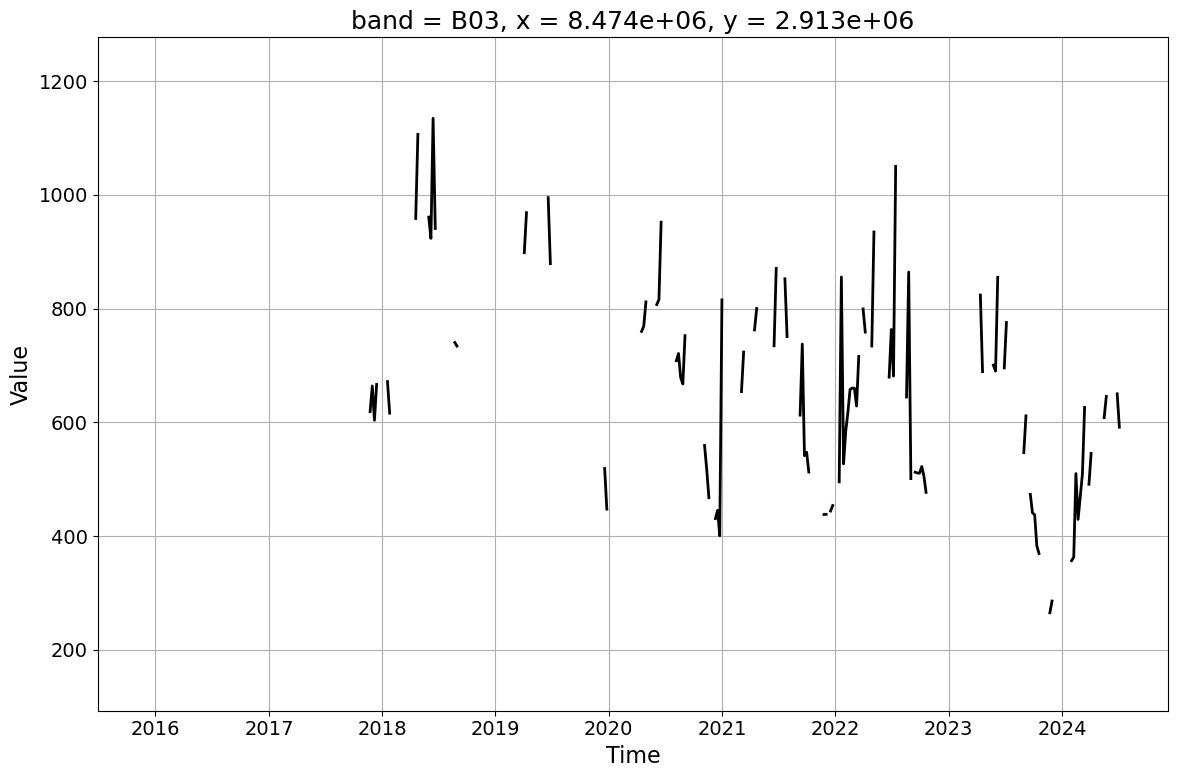

In [17]:

# Set font sizes for various components
plt.rcParams.update({
    'font.size': 14,           # Global font size
    'axes.titlesize': 18,      # Title font size
    'axes.labelsize': 16,      # X and Y label font size
    'xtick.labelsize': 14,     # X tick label font size
    'ytick.labelsize': 14,     # Y tick label font size
})

# Plot the time series
plt.figure(figsize=(12, 8))
pixel_timeseries.sentle.plot.line(color='black', linewidth=2)
#plt.title(f'Time Series for Band {band} at Pixel (x={x_pixel}, y={y_pixel})')
plt.xlabel('Time')
plt.ylabel('Value')
plt.grid(True)
plt.tight_layout()
plt.show()


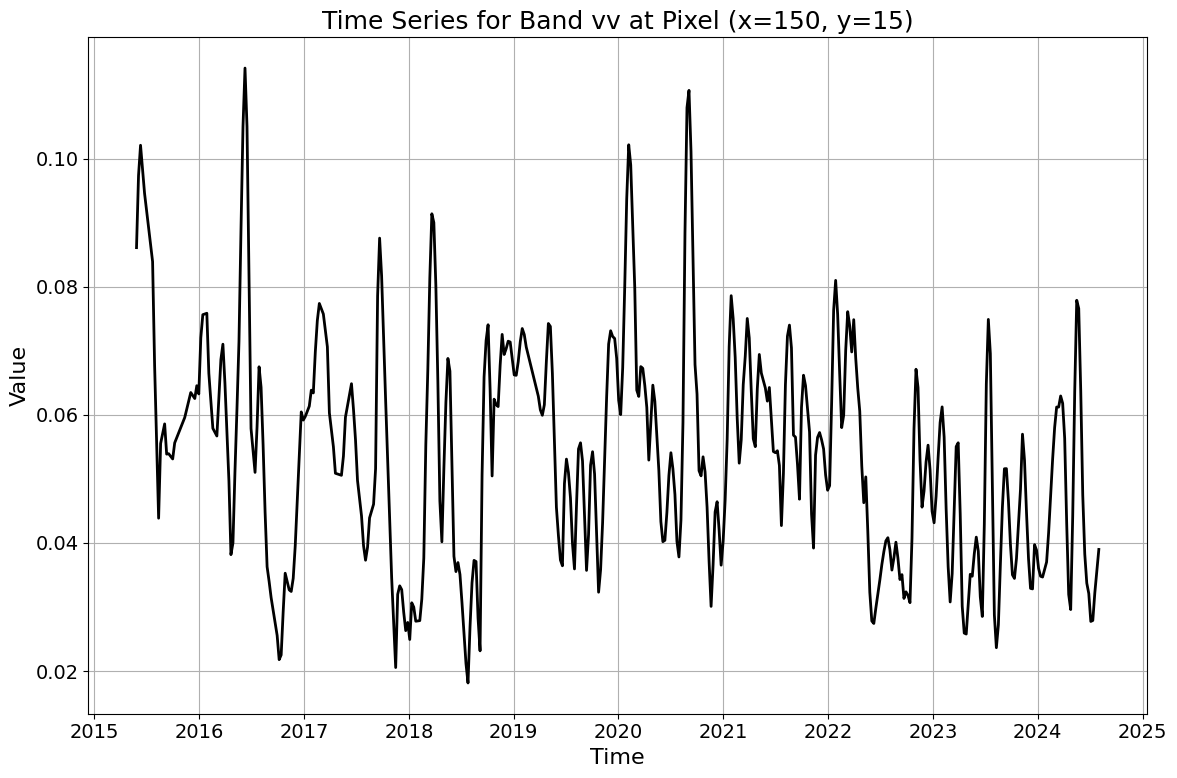

In [33]:
plot_timeseries(ds, 150, 15, 'vv')

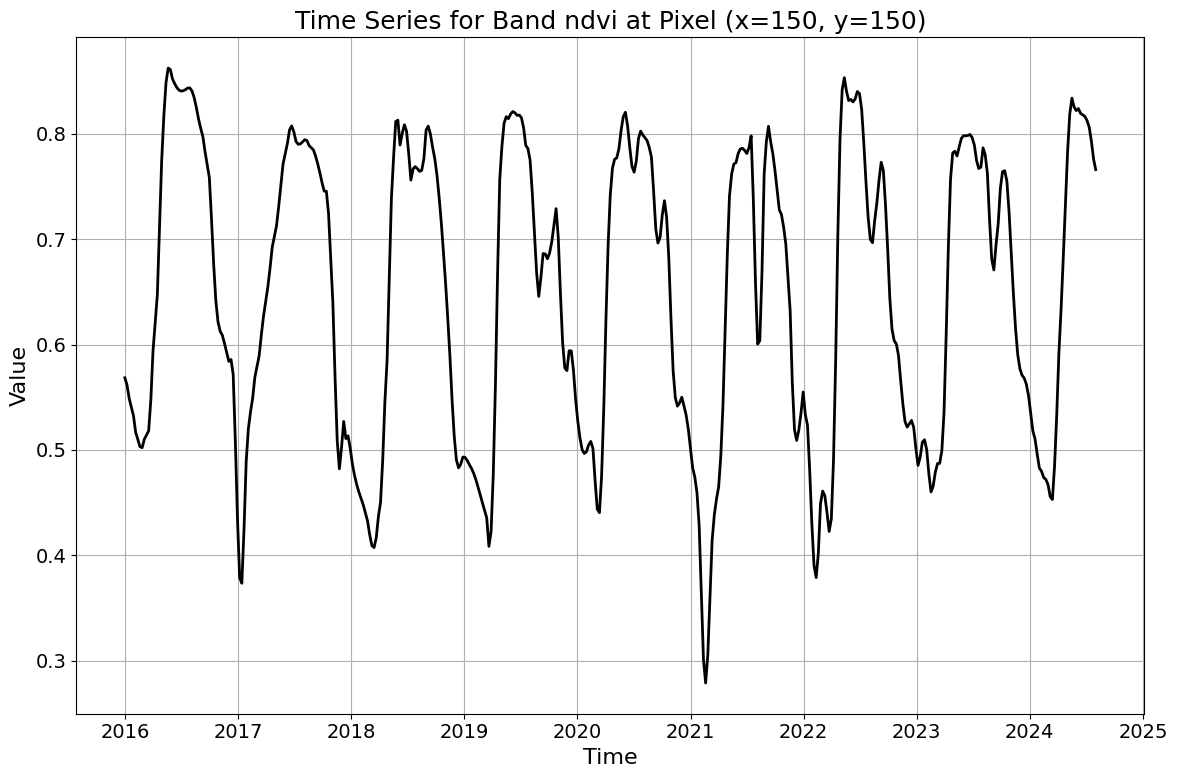

In [24]:
plot_timeseries(da, 150, 150, 'ndvi')

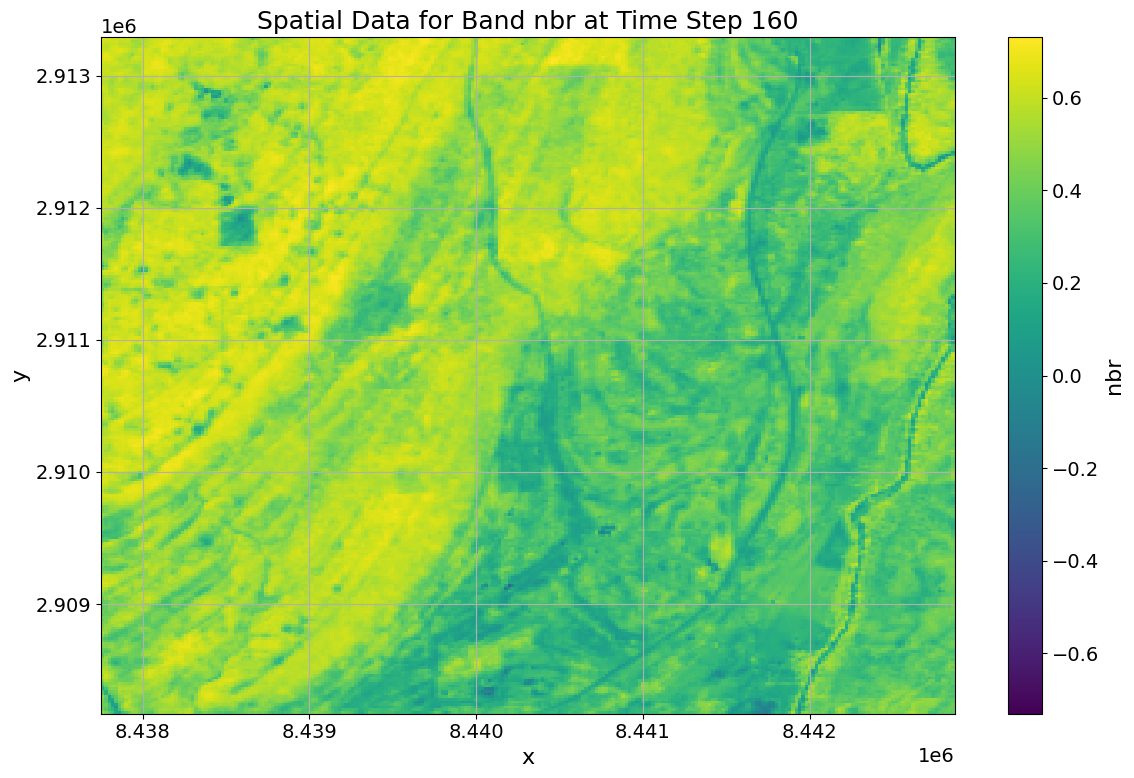

In [25]:
plot_minicube(da, 160, 'nbr')

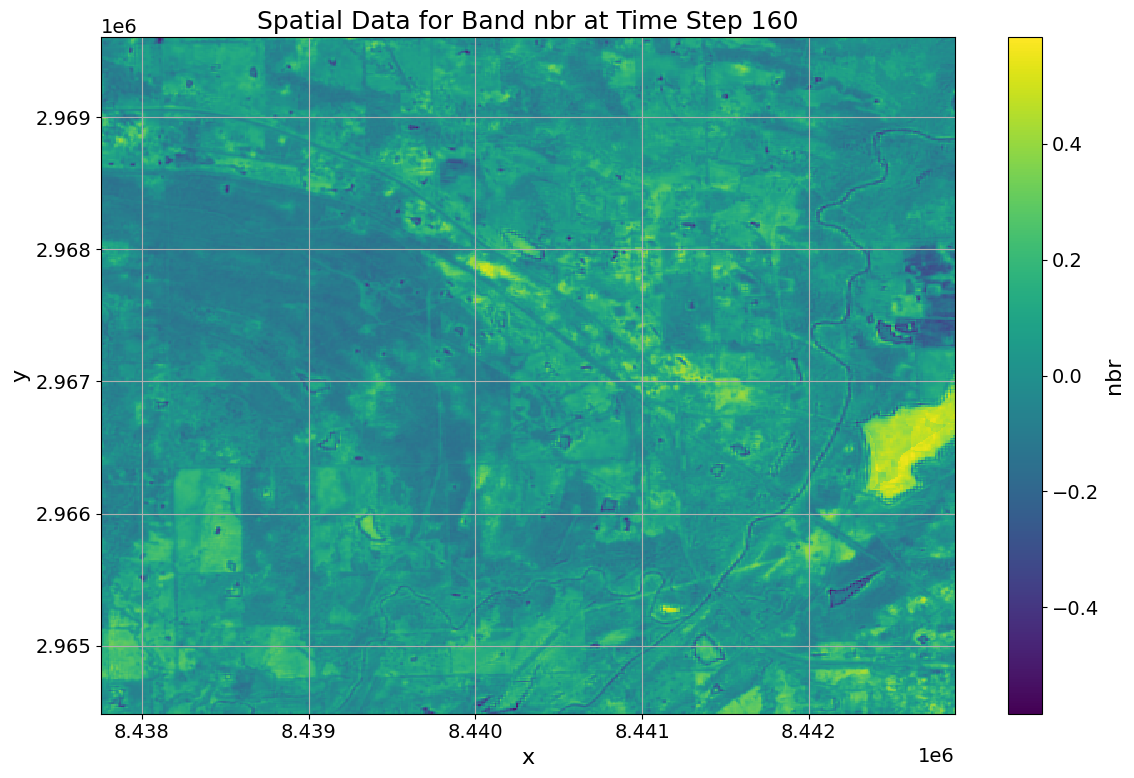

In [22]:
plot_minicube(ds, 160, 'nbr')